# Market EDA — Nifty 50 Stock Prices

Data pulled live from PostgreSQL (`finsight.stock_prices`, loaded via `src/db_connect.py`) — not from the raw CSV.
Explores missingness, return/volume distributions, cross-ticker return correlation (portfolio diversification), and return/volatility by ticker.
No default/fraud concept applies to market data, so the categorical breakdown here is the natural equivalent: mean daily return and volatility by ticker.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from db_connect import get_engine
from eda_utils import plot_distribution, plot_missing_map, plot_correlation_heatmap, sequential_shades

%matplotlib inline
pd.set_option("display.max_columns", 50)

engine = get_engine()
df = pd.read_sql(
    "SELECT ticker, trade_date, open_price, high_price, low_price, close_price, adj_close, volume, daily_return "
    "FROM finsight.stock_prices ORDER BY ticker, trade_date",
    engine,
)
print(f"finsight.stock_prices total rows: {len(df):,}")
print(f"Tickers: {sorted(df['ticker'].unique())}")
print(f"Date range: {df['trade_date'].min()} to {df['trade_date'].max()}")

finsight.stock_prices total rows: 6,195
Tickers: ['HDFCBANK.NS', 'ICICIBANK.NS', 'INFY.NS', 'RELIANCE.NS', 'TCS.NS']
Date range: 2021-07-30 to 2026-07-30


## Missing values

Unlike the loans/transactions tables, this one has genuine, explainable missingness: `daily_return` is NULL for each ticker's very first trading day (no prior close to compute a return from).

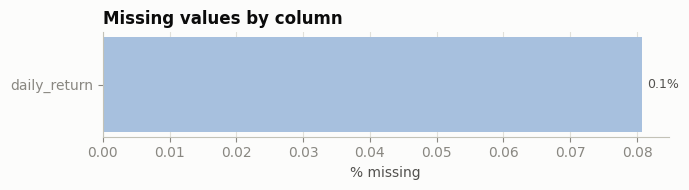

daily_return missing: 5 rows (0.081% of table) = exactly one per ticker (5 tickers)


In [2]:
fig, ax = plt.subplots(figsize=(7, 2))
plot_missing_map(df, ax=ax)
plt.show()

n_missing_return = df["daily_return"].isna().sum()
print(f"daily_return missing: {n_missing_return} rows ({100*n_missing_return/len(df):.3f}% of table) "
      f"= exactly one per ticker ({df['ticker'].nunique()} tickers)")

## Distributions of daily return and volume

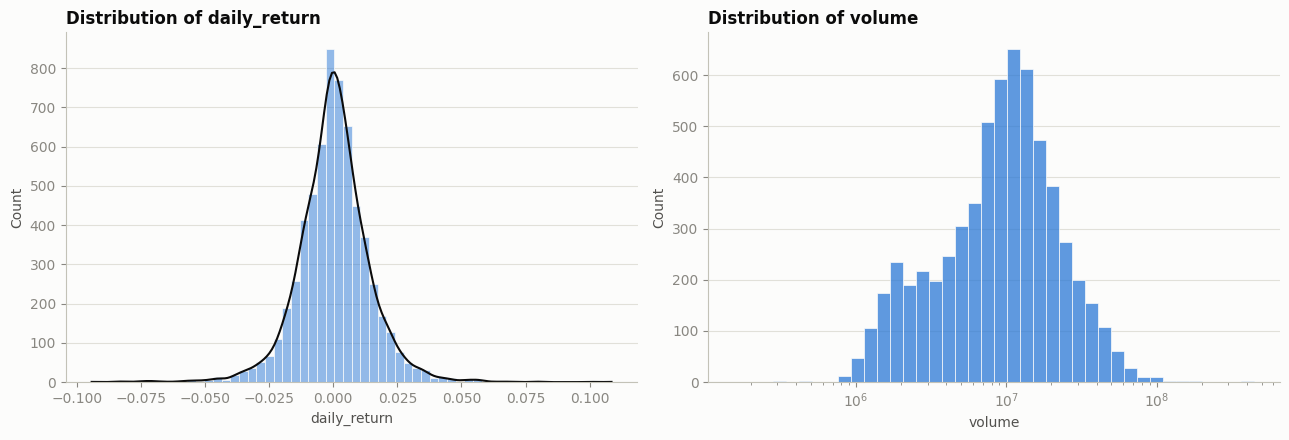

daily_return: mean=0.00025, std=0.01409, min=-0.0942, max=0.1085
Worst single-day return: INFY.NS 2023-04-17 = -9.42%
Best single-day return: ICICIBANK.NS 2021-10-25 = 10.85%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_distribution(df, "daily_return", ax=axes[0], bins=60)
plot_distribution(df, "volume", ax=axes[1], log_scale=True, kde=False)
fig.tight_layout()
plt.show()

print(f"daily_return: mean={df['daily_return'].mean():.5f}, std={df['daily_return'].std():.5f}, "
      f"min={df['daily_return'].min():.4f}, max={df['daily_return'].max():.4f}")
worst_day = df.loc[df["daily_return"].idxmin()]
best_day = df.loc[df["daily_return"].idxmax()]
print(f"Worst single-day return: {worst_day['ticker']} {worst_day['trade_date']} = {worst_day['daily_return']*100:.2f}%")
print(f"Best single-day return: {best_day['ticker']} {best_day['trade_date']} = {best_day['daily_return']*100:.2f}%")

## Correlation heatmap — daily returns across tickers

Pivoted wide (one column per ticker) so the heatmap shows genuine cross-stock portfolio correlation, rather than the trivially-high correlation you'd get from OHLC fields within a single ticker.

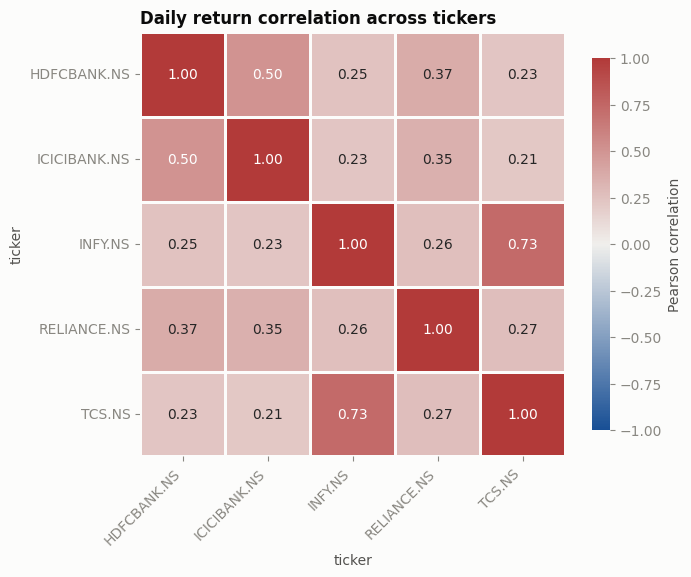

Ranked ticker-pair correlations:
  TCS.NS vs INFY.NS: 0.734
  HDFCBANK.NS vs ICICIBANK.NS: 0.504
  HDFCBANK.NS vs RELIANCE.NS: 0.368
  ICICIBANK.NS vs RELIANCE.NS: 0.347
  RELIANCE.NS vs TCS.NS: 0.273
  INFY.NS vs RELIANCE.NS: 0.263
  INFY.NS vs HDFCBANK.NS: 0.247
  INFY.NS vs ICICIBANK.NS: 0.232
  HDFCBANK.NS vs TCS.NS: 0.231
  ICICIBANK.NS vs TCS.NS: 0.211


In [4]:
returns_wide = df.pivot(index="trade_date", columns="ticker", values="daily_return")

fig, ax = plt.subplots(figsize=(7, 6))
plot_correlation_heatmap(returns_wide, columns=returns_wide.columns.tolist(), ax=ax,
                          title="Daily return correlation across tickers")
plt.show()

corr = returns_wide.corr()
corr_pairs = corr.where(~np.eye(len(corr), dtype=bool)).abs().unstack().dropna().sort_values(ascending=False)
seen = set()
print("Ranked ticker-pair correlations:")
for idx, val in corr_pairs.items():
    key = frozenset(idx)
    if len(key) < 2 or key in seen:
        continue
    seen.add(key)
    print(f"  {idx[0]} vs {idx[1]}: {corr.loc[idx]:.3f}")

## Average return & annualized volatility by ticker

,ticker,annualized_return_pct,annualized_volatility_pct,count
1,ICICIBANK.NS,19.44,20.22,1238
3,RELIANCE.NS,9.83,22.35,1238
0,HDFCBANK.NS,4.78,20.94,1238
4,TCS.NS,-0.03,22.28,1238
2,INFY.NS,-0.65,25.68,1238


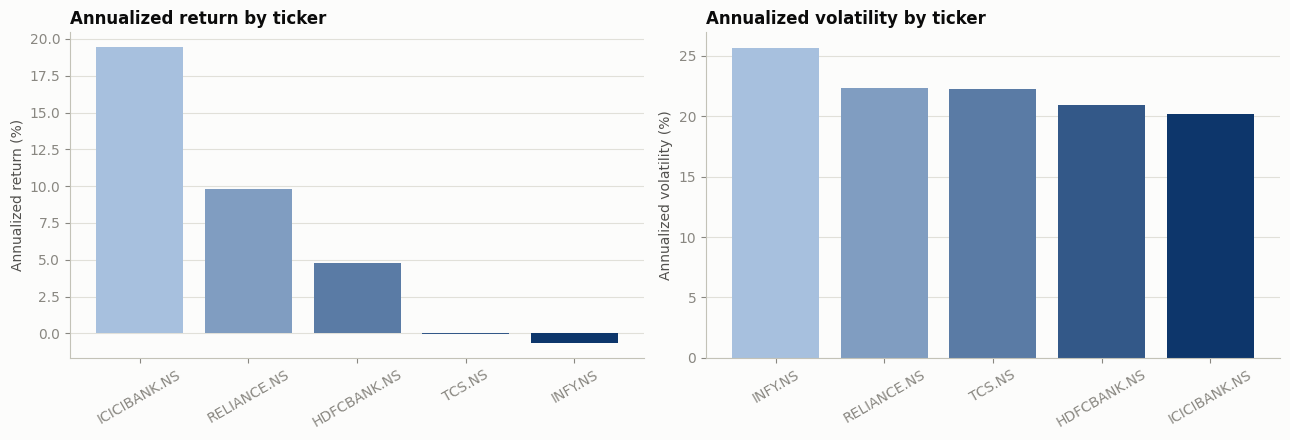

Best annualized return: ICICIBANK.NS at 19.4%
Worst annualized return: INFY.NS at -0.6%
Most volatile: INFY.NS at 25.7% annualized vol
Least volatile: ICICIBANK.NS at 20.2% annualized vol


In [5]:
by_ticker = df.groupby("ticker")["daily_return"].agg(["mean", "std", "count"]).reset_index()
by_ticker["annualized_return_pct"] = ((1 + by_ticker["mean"]) ** 252 - 1) * 100
by_ticker["annualized_volatility_pct"] = by_ticker["std"] * np.sqrt(252) * 100
by_ticker = by_ticker.sort_values("annualized_return_pct", ascending=False)
display(by_ticker[["ticker", "annualized_return_pct", "annualized_volatility_pct", "count"]].round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colors = sequential_shades(len(by_ticker))
axes[0].bar(by_ticker["ticker"], by_ticker["annualized_return_pct"], color=colors)
axes[0].set_title("Annualized return by ticker", loc="left", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Annualized return (%)")
axes[0].grid(axis="x", visible=False)
axes[0].tick_params(axis="x", rotation=30)

by_vol = by_ticker.sort_values("annualized_volatility_pct", ascending=False)
colors2 = sequential_shades(len(by_vol))
axes[1].bar(by_vol["ticker"], by_vol["annualized_volatility_pct"], color=colors2)
axes[1].set_title("Annualized volatility by ticker", loc="left", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Annualized volatility (%)")
axes[1].grid(axis="x", visible=False)
axes[1].tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

best = by_ticker.iloc[0]
worst = by_ticker.iloc[-1]
most_volatile = by_vol.iloc[0]
least_volatile = by_vol.iloc[-1]
print(f"Best annualized return: {best['ticker']} at {best['annualized_return_pct']:.1f}%")
print(f"Worst annualized return: {worst['ticker']} at {worst['annualized_return_pct']:.1f}%")
print(f"Most volatile: {most_volatile['ticker']} at {most_volatile['annualized_volatility_pct']:.1f}% annualized vol")
print(f"Least volatile: {least_volatile['ticker']} at {least_volatile['annualized_volatility_pct']:.1f}% annualized vol")

## Key Insights

1. **Sector clustering is visible directly in the correlation matrix**: TCS.NS and INFY.NS (both IT services) correlate at 0.73 - by far the highest pair - while HDFCBANK.NS and ICICIBANK.NS (both banks) correlate at 0.50, the second highest. Every cross-sector pair sits at 0.21-0.37. A portfolio split across IT and banking would diversify meaningfully better than picking two stocks from either sector.
2. **ICICIBANK.NS has the best risk-adjusted profile of the five**: +19.4% annualized return with the *lowest* volatility in the set (20.2% annualized). INFY.NS has the worst combination in the other direction: -0.6% annualized return with the *highest* volatility (25.7%) - underperforming while also being the riskiest holding.
3. **Daily returns cluster tightly around zero but carry real tail risk**: mean daily return is +0.025% with a 1.41% standard deviation, yet the single worst day was INFY.NS at -9.42% (2023-04-17) and the single best was ICICIBANK.NS at +10.85% (2021-10-25) - both roughly 7x the typical daily swing.
4. **Missingness here is genuine and fully explained**, unlike the loans/transactions tables (which showed ~0% after cleaning): `daily_return` is null for exactly 5 rows (0.081% of the table) - one per ticker, the first trading day with no prior close to compute a return from. That the count matches the ticker count exactly (5 of 5) confirms the pipeline is behaving correctly rather than silently dropping data elsewhere.
5. **Volume is heavily right-skewed**, needing a log scale to read - the same shape seen in the fraud dataset's `amount` field - consistent with occasional very-high-volume days (earnings, index rebalancing, block trades) sitting on top of a much smaller everyday baseline.
